cleaning up all over again

In [1]:
cd /Users/ibehbehani/csm_pipeline

/Users/ibehbehani/csm_pipeline


In [2]:
from conv_reproj import match
from align_and_diff import a_d
from header_setup import read

from matplotlib import pyplot as plt
import numpy as np

from astropy.io import fits
from pm import pm_correct
from astropy import units as u
from astropy.wcs import WCS
import cmasher as cmr

from astropy.time import Time
from astropy.coordinates import SkyCoord

Match function imported.
running


In [3]:
from everything import full_analysis
from everything import plot_1d, plot_2d
from radial import radial_read
from dens import density_model

/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready to go!


In [4]:
import os

In [5]:
cd

/Users/ibehbehani


In [6]:
hr = 'Documents/research/from_server/Betelgeuse_TE_cont_R0.image.image.tt0.fits'
lr = 'Documents/research/from_server/Betelgeuse_all_cont_1-1.image.image.tt0.fits'

In [7]:
# hr = 'Documents/cuny_ms/jan29_data/from_server/Betelgeuse_TE_cont_R0.image.image.tt0.fits'
# lr = 'Documents/cuny_ms/jan29_data/from_server/Betelgeuse_all_cont_1-1.image.image.tt0.fits'


data3, data_1d3, radius3, data_dens_1d3, data_dens_2d3, data_plot3, info3 = full_analysis(hr,lr)
# this should be lr
info3['lr']['kspatres']
# this should be hr


False
First epoch shifted to second.
Header information imported.
Header information imported.


indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in param

Alignment and subtraction complete. Info dictionaries imported.


/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/astropy/units/quantity.py:676: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/myenv/lib/py

np.float64(0.040566339161841755)

In [8]:
color = ['C6','C0','C2','black']

In [9]:
def plot_1d_bkg(data_1d,data_dens_1d,info,radius,ax1_ymin=1e-2,ax2_ymin=1e-3, ax1_ymax=1e4,ax2_ymax=1e3,xmin=0,xmax=0.45, suptitle = "1D Radial Intensity and Density Plots using original dimension data"):
    '''
    plot 1d density and intensity functions.
    can select plot x and y limits. default values inputted otherwise
    '''


    fig, (ax1, ax2) = plt.subplots(2, 1, figsize = [8,11])
    fig.suptitle(suptitle, size= '25')

    title = ['hr','lr','reproj','csm', 'hr_dens','lr_dens', 'reproj_dens','csm_dens']
    labels = ['{res}"'.format(res = np.round(info['hr']['kspatres'],3)),
             '{res}"'.format(res = np.round(info['lr']['kspatres'],3)),
            'Reprojected {res}"'.format(res = np.round(info['hr']['kspatres'],3)),
            "CSM"]    
    
    plt.rcParams['font.sans-serif'] = ['Helvetica Neue']
    c=0
    j=0
    for j in range(len(title)):
        if j==4:
            c=0
        
        if j<4:
            ax1.plot(radius[title[c]]['arc_1d'],data_1d[title[c]].value,'o-',alpha=0.4, label = labels[c], c = color[c])
            ax1.errorbar(radius[title[c]]['arc_1d'],data_1d[title[c]].value,yerr=info[title[c]]['error'].value, c = color[c],alpha= .17)
        else:
            info[title[c]]['error_dens'] = density_model(info[title[c]]['error'],radius[title[c]]['pc_1d'])

            ax2.plot(radius[title[c]]['arc_1d'],data_dens_1d[title[c]].value,'o-',alpha=0.4,label = labels[c], c = color[c])
            ax2.errorbar(radius[title[c]]['arc_1d'],data_dens_1d[title[c]].value,yerr=info[title[c]]['error_dens'].value, c = color[c], alpha=.17)
    
        c+=1

    ax2.legend(loc = 'best', bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))
    # ax2.set_xlim(xmin,xmax)
    ax1.set_xlim(0,0.45)
    ax1.set_ylim(ax1_ymin, ax1_ymax)
    # ax2.set_ylim(ax2_ymin, ax2_ymax)

    ax1.semilogy()
    
    ax1.yaxis.set_ticks_position('both')
    ax2.yaxis.set_ticks_position('both')
    ax1.xaxis.set_ticks_position('both')
    ax2.xaxis.set_ticks_position('both')

    ax2.semilogy()
    # ax2.semilogx()
    ax1.tick_params(direction = 'in')
    ax2.tick_params(direction = 'in')


    ax1.set_title("Radial Intensity",size=18)
    ax2.set_title("Radial Density",size=18)
    ax1.set_xlabel('Radius (arc)',size=15)
    ax2.set_xlabel('Radius (arc)',size=15)
    ax1.set_ylabel(r'Intensity (Jy arc$^{-2}$)',size=15)
    ax2.set_ylabel(r'Density (g cm$^{-2}$)',size=15)
   

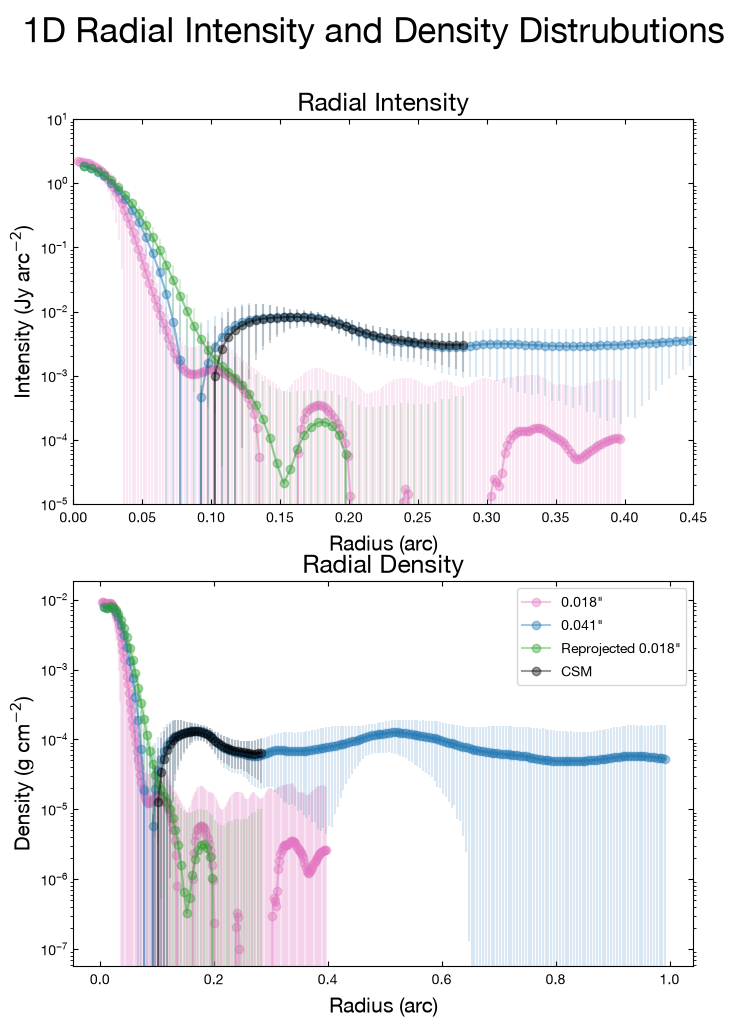

In [10]:
plot_1d_bkg(data_1d3, data_dens_1d3,info3,radius3,ax1_ymin=1e-5,ax1_ymax=1e1,ax2_ymin=1e-7,ax2_ymax=1e-1, 
        suptitle = "1D Radial Intensity and Density Distrubutions")#,xmax=0.35)
#plt.savefig('thesis/medhigh/1d_radial_all_MH.png')

#plot_1d(data_1d3, data_dens_1d3,info3,radius3,ax1_ymin=-1e-1,ax1_ymax=6e5,ax2_ymin=1e0,ax2_ymax=1e1)#,xmax=0.35)

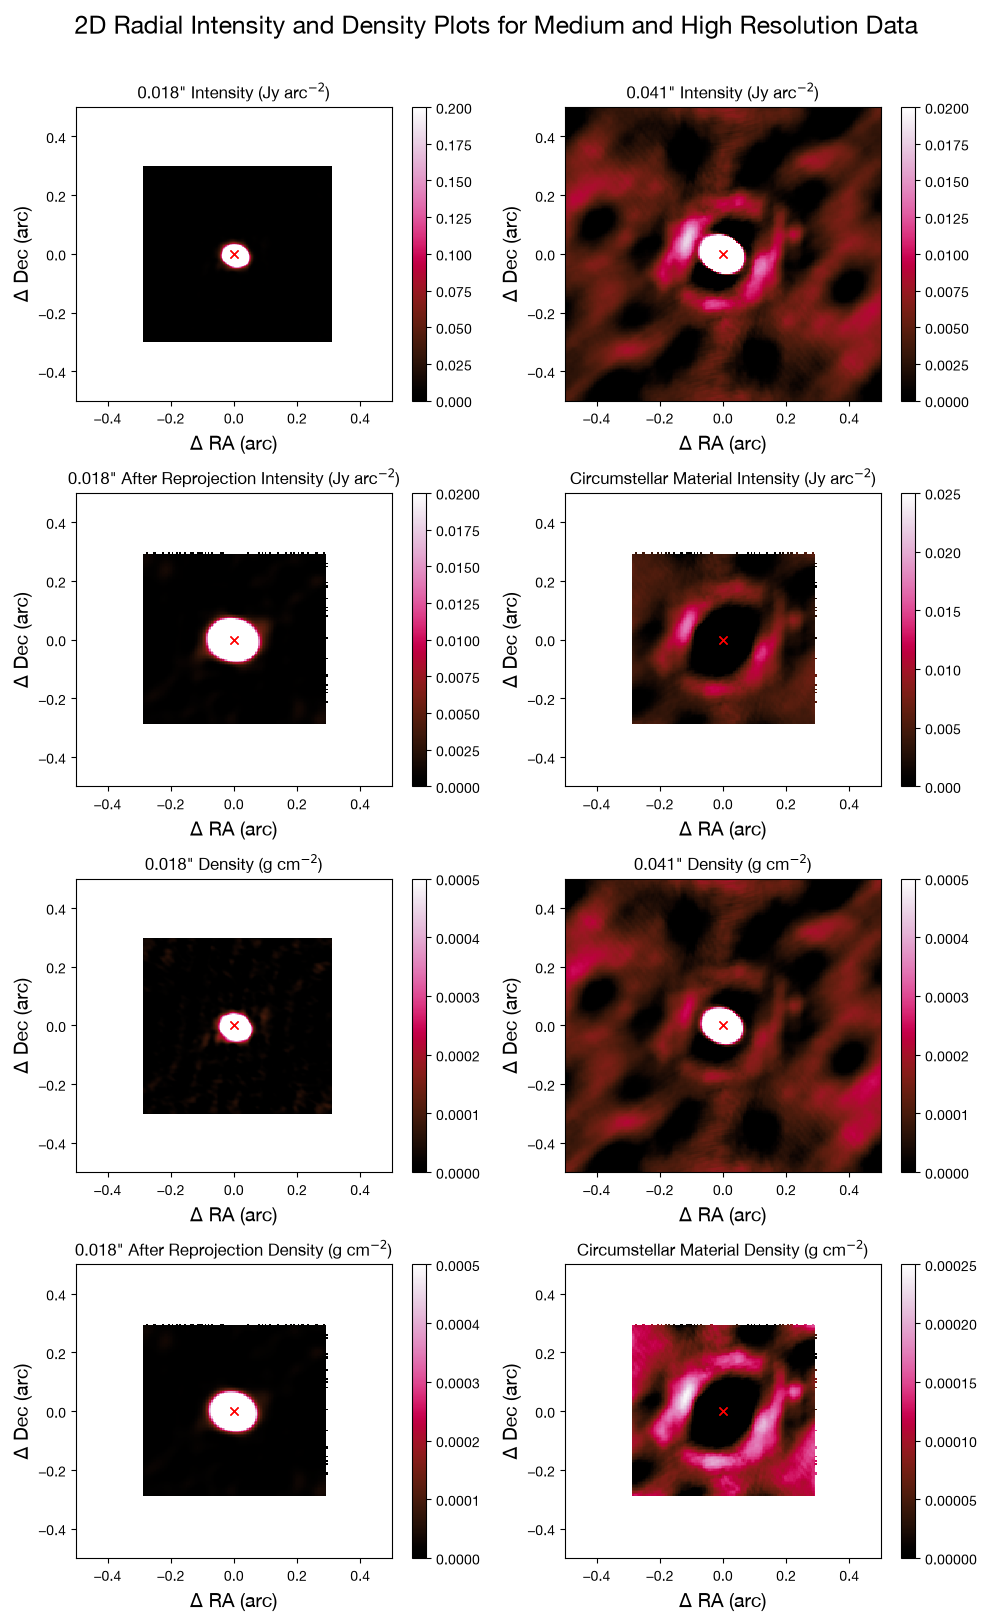

In [11]:
vminmax = [[0,.2], [0,.02],[0,.02],[0,0.025],
           [0,0.0005], [0,0.0005],[0,0.0005],[0,0.00025]]
plot_2d(data_plot3, info3, vminmax,minn=-.5, suptitle = "2D Radial Intensity and Density Plots for Medium and High Resolution Data")
#plt.savefig('thesis/medhigh/2D_plots_MH.png')

In [12]:
def plot12d2(data,info, suptitle,vminmax, minn=-.4, dense = False):
    maxx= -minn

    figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
    figure.suptitle(suptitle, fontsize = 18, y=1.01)

    xaxis = range(data.shape[0])*info['pix_size_arcsec']-((info['position'][0])*info['pix_size_arcsec'])
    yaxis = range(data.shape[1])*info['pix_size_arcsec']-((info['position'][1])*info['pix_size_arcsec'])


    im = ax.pcolormesh(yaxis,xaxis,data, cmap='gist_heat',shading="gouraud", vmin = vminmax[0], vmax = vminmax[1])
    # ax.plot((info['position'][1])*info['pix_size_arcsec']-((info['position'][1])*info['pix_size_arcsec']),
    #         (info['position'][0])*info['pix_size_arcsec']-((info['position'][0])*info['pix_size_arcsec']),'rx')
    # ax.plot(0,0,'rx')

    ax.set_xlim(minn, maxx)
    ax.set_ylim(minn, maxx)
    # plt.plot(476*info['pix_size_arcsec']-((info['position'][0])*info['pix_size_arcsec']),
    #          509*info['pix_size_arcsec']-((info['position'][1])*info['pix_size_arcsec']),'bx')
    #print(476*info['pix_size_arcsec']-((info['position'][0])*info['pix_size_arcsec']),
    #         509*info['pix_size_arcsec']-((info['position'][1])*info['pix_size_arcsec']))
    
    if(dense==False):
        figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')
    elif (dense == True):
        figure.colorbar(im,ax=ax, label=r'g cm$^{-2}$')

    ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
    ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)



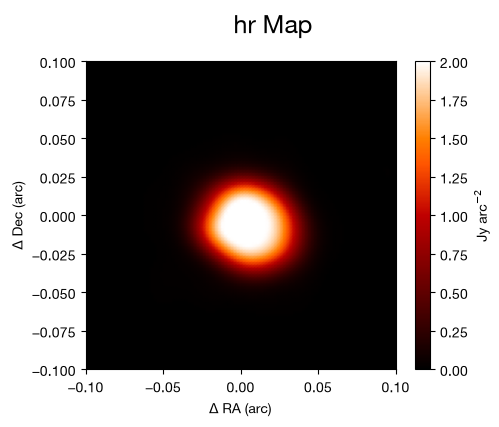

In [13]:
plot12d2(data3['hr']['jy_arc2'][0,0,...].value,info3['hr'],suptitle='hr Map', vminmax = [-0.0002,2],minn=-.1)

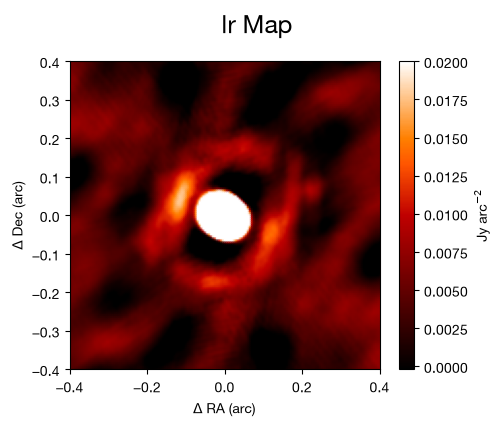

In [14]:
plot12d2(data3['lr']['jy_arc2'][0,0,...].value,info3['lr'],suptitle='lr Map', vminmax = [-0.0002,0.02],minn=-.4)

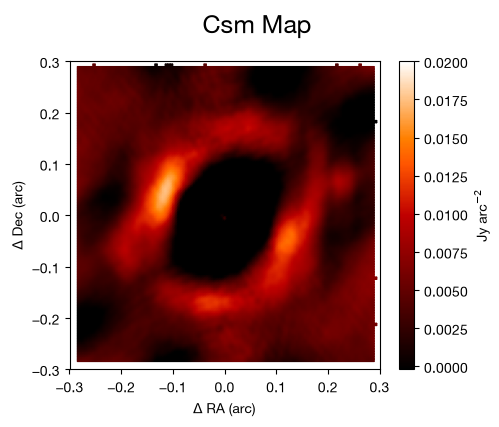

In [15]:
plot12d2(data3['csm']['jy_arc2'].value,info3['lr'],suptitle='Csm Map', vminmax = [-0.0002,0.02],minn=-.3)

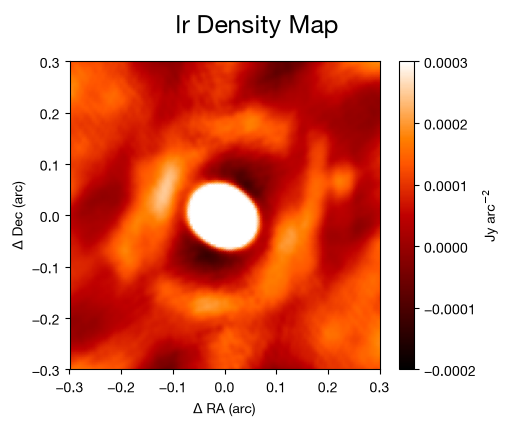

In [16]:
plot12d2(data_dens_2d3['lr'].value,info3['lr'],suptitle='lr Density Map', vminmax = [-0.0002,0.0003],minn=-0.3)

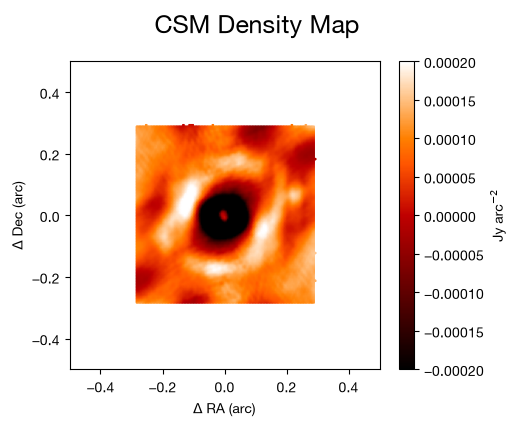

In [17]:
plot12d2(data_dens_2d3['csm'].value,info3['csm'],suptitle='CSM Density Map', vminmax = [-0.0002,0.0002],minn=-.5)

# Finding Rays

Now take resulting 2d surface density image, calculate azumuthal radial profiles to then apply an inverse abel transform to

In [18]:
## CUT IF ON HOME COMPUTER

In [19]:
cd /Users/ibehbehani/csm_pipeline

/Users/ibehbehani/csm_pipeline


In [20]:
from radial_interpolation import *

In [21]:
data_dens_2d3['csm'].value.shape

(1000, 1000)

In [22]:
from radial_interpolation import radial_interp

ImportError: cannot import name 'radial_interp' from 'radial_interpolation' (/Users/ibehbehani/csm_pipeline/radial_interpolation.py)

In [ ]:
x_grid,y_grid,interp_csm = radial_interp(data_dens_2d3['csm'].value, info3['csm']['position'][0],info3['csm']['position'][1],
              n_lines = 200, n_pts = 100)

NameError: name 'radial_interp' is not defined

## Abel transform

In [ ]:
from abel import all_abel, do_abel, plot_1d_abel

In [ ]:
d = {'hr': data_dens_1d3['hr'], 'lr': data_dens_1d3['lr'], 'reproj': data_dens_1d3['reproj'],"csm": data_dens_1d3['csm']}
i = {'hr': info3['hr'], 'lr': info3['lr'], 'reproj': info3['reproj'],"csm": info3['csm']}

In [ ]:
print(info3['hr']['median'])
print(info3['reproj']['median'])
print(info3['lr']['median'])
print(info3['csm']['median'])


2.7049269580517033e-05
8.418014260236199e-05
0.0010701067859508304
0.0044229718265451756


In [ ]:
print(info3['hr']['median_dens'])
print(info3['reproj']['median_dens'])
print(info3['lr']['median_dens'])
print(info3['csm']['median_dens'])


8.773863086349733e-07 g / cm2
1.493734508648048e-06 g / cm2
6.603274608302551e-05 g / cm2
8.705565119122754e-05 g / cm2


In [ ]:
csm_bkg = np.sqrt(info3['reproj']['median_dens']**2+info3['lr']['median_dens']**2)

In [ ]:
def all_abel(data,rad,info):
    print("here i am!")
    titles = list(data.keys())
    f_rs = {}

    for t in titles:
        print(t)
        print("max:", np.nanmax(data[t].value))
        print("median dens: ", info[t]['median_dens'])
        if(t=="csm"):
            f_rs[t] = do_abel(data[t].value,rad[t]['pc_1d'].to(u.cm).value,info[t]['median_dens']/100)
            #f_rs[t] = do_abel(data[t].value,rad[t]['pc_1d'].to(u.cm).value,csm_bkg)
        else:
            f_rs[t] = do_abel(data[t].value,rad[t]['pc_1d'].to(u.cm).value,info[t]['median_dens'])

    return f_rs



def do_abel(F_arr,s,med):
    '''
    F = radial profile of surface density
    s = radii corresponding with radial profile
    med = background median- sets all neg values in F array to bkg median
    '''
    print()
    med = med/10
    F = F_arr.copy() # copy density array to prevent overwriting
    F[F<0] = med # turn negative values into background median
    dF_ds = np.gradient(F,s) 
    dF_ds = dF_ds[~np.isnan(dF_ds)] #this likely only works for this data bc it 
    s = s[:len(dF_ds)] # only cuts off nans if theyre all at the end of image
    f_r = np.zeros(len(s))
    r_arr = np.zeros(len(s))

    for i in range(len(s)-1):
        r = (s[i]+s[i+1])/2
        r_arr[i] = r

        integ = np.trapezoid(dF_ds[i+1:]/ np.sqrt(s[s>r]**2-r**2),s[s>r])

        f_r[i]= (-1/np.pi)* integ # integrate from r to highest radial value

    # print(f_r)

    return f_r

In [ ]:
abels = all_abel(d,radius3,i)

here i am!
hr
max: 0.009254187509873982
median dens:  8.773863086349733e-07 g / cm2

lr
max: 0.007868730005393001
median dens:  6.603274608302551e-05 g / cm2

reproj
max: 0.008077290844688986
median dens:  1.493734508648048e-06 g / cm2

csm
max: 0.00013191192632824378
median dens:  8.705565119122754e-05 g / cm2



/Users/ibehbehani/csm_pipeline/abel.py:96: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


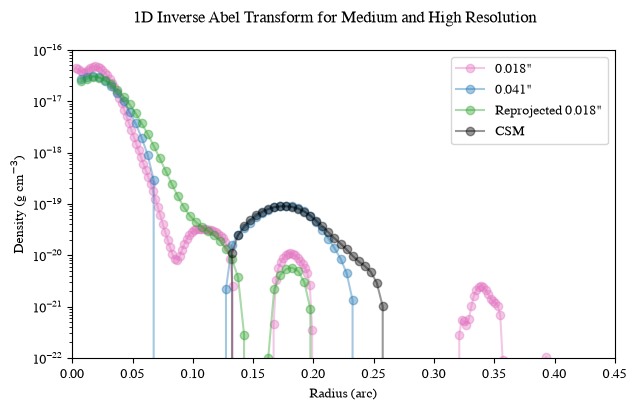

In [ ]:
plot_1d_abel(abels,info3,radius3,ax_ymin=1e-22,ax_ymax=1e-16,xmax=0.3, suptitle = "1D Inverse Abel Transform for Medium and High Resolution")


In [ ]:
def plot_1d_abel_massloss_bkg(data_abel_1d,info,radius,ax_ymin=1e-2, ax_ymax=1e4,xmin=0,xmax=0.45, suptitle = "1D Abel Transformation (g/cm3)", dent=False):
    '''
    plot 1d density and intensity functions.
    can select plot x and y limits. default values inputted otherwise
    '''

    fig, ax = plt.subplots(1, 1, figsize = [7,4])
    fig.suptitle(suptitle)

    title = ['hr','lr','reproj','csm']
    labels = ['{res}"'.format(res = np.round(info['hr']['kspatres'],3)),
             '{res}"'.format(res = np.round(info['lr']['kspatres'],3)),
               'Reprojected {res}"'.format(res = np.round(info['hr']['kspatres'],3)),
                 "CSM"]    
    
    for j in range(len(title)):
        # print(len(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])]))
        # print((data_abel_1d[title[j]]*430).shape)
        ax.fill_between(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])],data_abel_1d[title[j]]+data_abel_1d[title[j]]*430,data_abel_1d[title[j]]+data_abel_1d[title[j]]*1000,alpha=0.4, label = labels[j], color = color[j])
        #ax.plot(radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])],data_abel_1d[title[j]]*200,'o-',alpha=0.4, label = labels[j], c = color[j])
            #ax.errorbar(radius[title[c]]['arc_1d'],data_1d[title[c]].value,yerr=info[title[c]]['error'].value, c = color[c])

    x = (radius[title[j]]['arc_1d'][:len(data_abel_1d[title[j]])]).value
    increment = np.arange(0,len(x),x[1]-x[0])
    #y = (data_abel_1d[title[j]][0]*716)*(10)**(-x) #abels['hr'][0]
    y = (data_abel_1d['lr'][0]*716)*10**(-x)
 

    xlr = (radius[title[j]]['arc_1d'][:len(abels['lr'])]).value    
    xlr_cm = (radius[title[j]]['pc_1d'][:len(abels['lr'])]).to(u.cm)    
    xlr_rsun = (radius[title[j]]['pc_1d'][:len(abels['lr'])]).to(u.Rsun)  
    dlr = np.gradient(abels['lr']*716,0.005)
    # # print("dlr", dlr)
    # # print("y!",716*abels['lr'][0]*10**(dlr*xlr))

    v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)
    v_s = (1e6*u.cm/u.s)

    Mlr = radius3['lr']['pc_1d'].to(u.cm)**2* (716*abels['lr']*u.g/u.cm**3).to(u.M_sun/u.cm**3) *4*np.pi*(1e6*u.cm/u.s).to(u.cm/u.yr)
    
    #ax.plot(xlr, Mlr.to(u.g/u.s) / (4*np.pi*xlr_cm**2*v_s), label = r'$\dot M = 4 \pi r^2 \rho v$')


    mdotexp = [-8,-7,-6,-5,-4]# msun/yr

    for mdot in mdotexp:
        print(mdot)

        rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*xlr_cm**2*v_yr)
        ax.plot(xlr, rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

        xtext = xlr[1]
        ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/13

        print(xtext,ytext)


        ax.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
                rotation=-20, alpha = 0.6)


    # ax.plot(xlr, 716*abels['lr'][0]*10**(dlr*xlr), color = 'gray', ls  = '--', label = 'LR deriv ~10**(-13)')
    ax.legend(loc = 'upper right')#, bbox_to_anchor=(.85, 0.5, 0.5, 0.5))
    ax.semilogy()
    ax.semilogx()
#     ax.set_title("1-D Density (g/cm3)")
    ax.set_xlim(xmin,xmax)
    ax.set_ylim(ax_ymin, ax_ymax)


    ax.set_xlabel('Radius (arcseconds)')
    ax.set_ylabel(r'Density (g cm$^{-3}$)')

-8
0.012500000000001 4.1463906183997455e-18 g / cm3
-7
0.012500000000001 4.1463906183997455e-17 g / cm3
-6
0.012500000000001 4.1463906183997457e-16 g / cm3
-5
0.012500000000001 4.146390618399746e-15 g / cm3
-4
0.012500000000001 4.146390618399746e-14 g / cm3


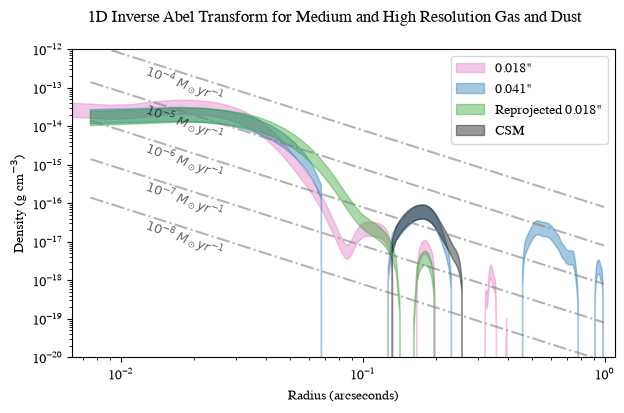

In [ ]:
plot_1d_abel_massloss_bkg(abels,info3,radius3,ax_ymin=1e-20,ax_ymax=1e-12, xmin= 1*10**-2.2,xmax=1.1, suptitle = "1D Inverse Abel Transform for Medium and High Resolution Gas and Dust" ,dent = True)
